# Logistic Regression | Titanic Survival Prediction

Predict whether a passenger survived the Titanic disaster (binary classification: 1 = survived, 0 = did not survive).

Logistic Regression is the natural starting point for binary classification. The output is a probability between 0 and 1, which maps directly to survival likelihood. The coefficients are interpretable -- you can read them and explain exactly why the model predicted survival or death for any individual passenger. No other model gives you that level of transparency.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Inspect Data

In [3]:
# UPDATE THIS PATH to where your Titanic.csv is located
df = pd.read_csv('../../Datasets/Titanic/Titanic.csv')

# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

print(f"Shape: {df.shape}")
print()
print("Column overview:")
for col in df.columns:
    dtype  = df[col].dtype
    nulls  = df[col].isnull().sum()
    nuniq  = df[col].nunique()
    print(f"  {col:<15} dtype={str(dtype):<10} nulls={nulls:<4} unique={nuniq}")

Shape: (891, 15)

Column overview:
  survived        dtype=int64      nulls=0    unique=2
  pclass          dtype=int64      nulls=0    unique=3
  sex             dtype=object     nulls=0    unique=2
  age             dtype=float64    nulls=177  unique=88
  sibsp           dtype=int64      nulls=0    unique=7
  parch           dtype=int64      nulls=0    unique=7
  fare            dtype=float64    nulls=0    unique=248
  embarked        dtype=object     nulls=2    unique=3
  class           dtype=object     nulls=0    unique=3
  who             dtype=object     nulls=0    unique=3
  adult_male      dtype=bool       nulls=0    unique=2
  deck            dtype=object     nulls=688  unique=7
  embark_town     dtype=object     nulls=2    unique=3
  alive           dtype=object     nulls=0    unique=2
  alone           dtype=bool       nulls=0    unique=2


In [ ]:

# We use the original raw columns only, and engineer our own features on top.
# Using pre-made derived columns would skip the learning process.

print("Target distribution:")
print(df['survived'].value_counts())
print()
survival_rate = df['survived'].mean()
print(f"Overall survival rate: {survival_rate:.1%}")
print()
print(f"A naive model that always predicts 'did not survive' achieves {1 - survival_rate:.1%} accuracy.")
print("This is the baseline we must beat.")

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.4%

A naive model that always predicts 'did not survive' achieves 61.6% accuracy.
This is the baseline we must beat.


## 2. Exploratory Data Analysis

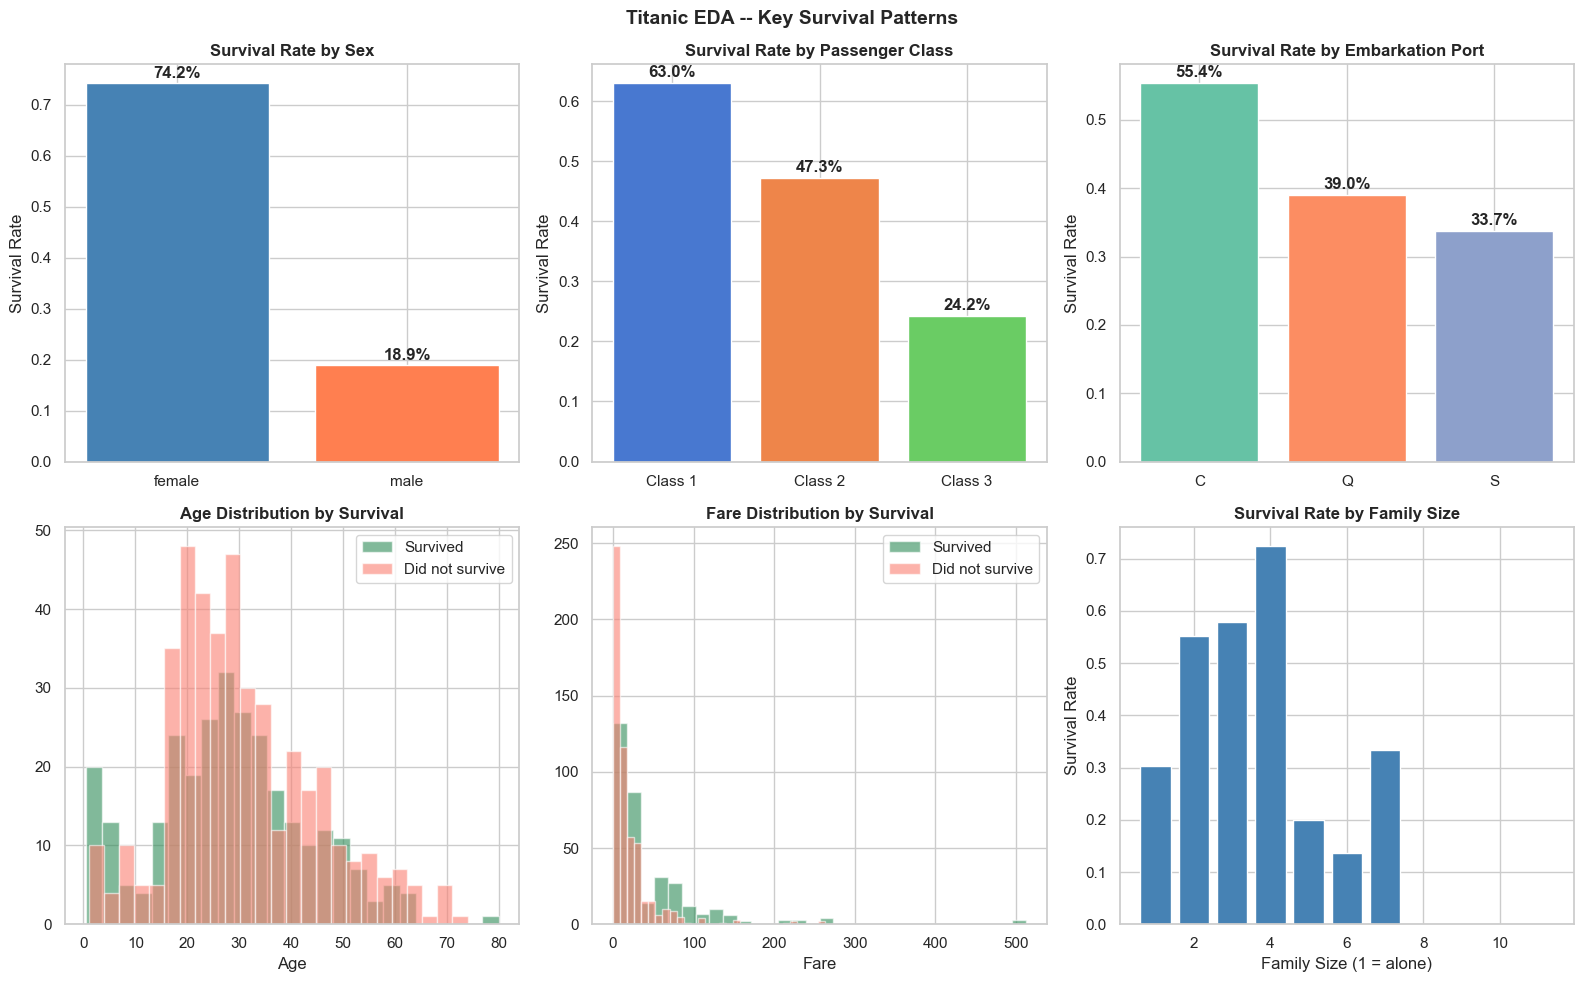

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Survival by sex
survival_by_sex = df.groupby('sex')['survived'].mean()
axes[0,0].bar(survival_by_sex.index, survival_by_sex.values, color=['steelblue', 'coral'])
axes[0,0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_sex.values):
    axes[0,0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Survival by class
survival_by_class = df.groupby('pclass')['survived'].mean()
axes[0,1].bar([f'Class {c}' for c in survival_by_class.index],
              survival_by_class.values, color=sns.color_palette('muted'))
axes[0,1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[0,1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Survival by embarkation port
survival_by_emb = df.groupby('embarked')['survived'].mean().dropna()
axes[0,2].bar(survival_by_emb.index, survival_by_emb.values, color=sns.color_palette('Set2'))
axes[0,2].set_title('Survival Rate by Embarkation Port', fontweight='bold')
axes[0,2].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_emb.values):
    axes[0,2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Age distribution by survival
df[df['survived']==1]['age'].dropna().hist(ax=axes[1,0], bins=25, alpha=0.6,
                                            color='seagreen', label='Survived')
df[df['survived']==0]['age'].dropna().hist(ax=axes[1,0], bins=25, alpha=0.6,
                                            color='salmon', label='Did not survive')
axes[1,0].set_title('Age Distribution by Survival', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Fare distribution by survival
df[df['survived']==1]['fare'].hist(ax=axes[1,1], bins=30, alpha=0.6,
                                    color='seagreen', label='Survived')
df[df['survived']==0]['fare'].hist(ax=axes[1,1], bins=30, alpha=0.6,
                                    color='salmon', label='Did not survive')
axes[1,1].set_title('Fare Distribution by Survival', fontweight='bold')
axes[1,1].set_xlabel('Fare')
axes[1,1].legend()

# Family size vs survival
df['family_size_temp'] = df['sibsp'] + df['parch'] + 1
survival_by_family = df.groupby('family_size_temp')['survived'].mean()
axes[1,2].bar(survival_by_family.index, survival_by_family.values, color='steelblue')
axes[1,2].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1,2].set_xlabel('Family Size (1 = alone)')
axes[1,2].set_ylabel('Survival Rate')
df.drop(columns='family_size_temp', inplace=True)

plt.suptitle('Titanic EDA -- Key Survival Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
print("Survival rates by sex:")
print(df.groupby('sex')['survived'].mean().round(3))
print()
print("Survival rates by class and sex:")
print(df.groupby(['pclass', 'sex'])['survived'].mean().unstack().round(3))
print()
print("A first-class female had the highest survival probability.")
print("A third-class male had the lowest.")
print("Logistic Regression will learn exactly these patterns and encode them as coefficients.")

Survival rates by sex:
sex
female    0.742
male      0.189
Name: survived, dtype: float64

Survival rates by class and sex:
sex     female   male
pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135

A first-class female had the highest survival probability.
A third-class male had the lowest.
Logistic Regression will learn exactly these patterns and encode them as coefficients.


## 3. Missing Value Handling

In [7]:
print("Missing values before handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Age: 177 missing
# Strategy: group by pclass and sex, fill with group median
# Passengers in the same class and sex have similar age profiles
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: 2 missing
# Strategy: fill with mode -- Southampton was by far the most common port
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Deck: 688 missing out of 891 (77%)
# Too many missing values to impute meaningfully -- drop this column
df.drop(columns=['deck'], inplace=True)

remaining = df.isnull().sum().sum()
print(f"Missing values remaining: {remaining}")

Missing values before handling:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Missing values remaining: 2


## 4. Feature Engineering

In [8]:
# Use only raw original columns -- drop all pre-derived columns from the seaborn version
# 'alive' is a string version of the target -- using it as a feature would be leakage
df_model = df.drop(
    columns=['class', 'who', 'adult_male', 'alive', 'alone', 'embark_town'],
    errors='ignore'
).copy()

# Feature 1: Family size
df_model['family_size'] = df_model['sibsp'] + df_model['parch'] + 1

# Feature 2: Is alone
df_model['is_alone'] = (df_model['family_size'] == 1).astype(int)

# Feature 3: Fare per person -- corrects for family members sharing a ticket price
df_model['fare_per_person'] = df_model['fare'] / df_model['family_size']

# Feature 4: Child flag -- lifeboat priority was given to children
df_model['is_child'] = (df_model['age'] < 16).astype(int)

# Feature 5: Age x class interaction
# A young first-class passenger and a young third-class passenger had very different outcomes
df_model['age_class'] = df_model['age'] * df_model['pclass']

# Encode sex as binary
df_model['sex_encoded'] = (df_model['sex'] == 'female').astype(int)

# One-hot encode embarkation port
embarked_dummies = pd.get_dummies(df_model['embarked'], prefix='embarked',
                                   drop_first=True, dtype=int)
df_model = pd.concat([df_model, embarked_dummies], axis=1)

# Drop original categorical columns now that they are encoded
df_model.drop(columns=['sex', 'embarked'], inplace=True)

feature_cols = [c for c in df_model.columns if c != 'survived']
print("Final features:")
for col in feature_cols:
    print(f"  {col}")
print(f"\nTotal: {len(feature_cols)} features")

Final features:
  pclass
  age
  sibsp
  parch
  fare
  family_size
  is_alone
  fare_per_person
  is_child
  age_class
  sex_encoded
  embarked_Q
  embarked_S

Total: 13 features


## 5. The Math Behind Logistic Regression

**Why not Linear Regression for classification?**

Linear Regression predicts unbounded values, which cannot be interpreted as probabilities. We need output that is always between 0 and 1.

**The sigmoid function:**
```
sigmoid(z) = 1 / (1 + e^(-z))
```
Maps any real number to a value between 0 and 1.

**The full model:**
```
z     = w0 + w1*x1 + w2*x2 + ... + wn*xn
p     = 1 / (1 + e^(-z))
y_hat = 1 if p >= 0.5 else 0
```

**Loss function (Log Loss, not MSE):**
```
Loss = -(1/n) * sum(y * log(p) + (1-y) * log(1-p))
```
Heavily penalizes confident wrong predictions.

**Odds ratio interpretation:**
The exponentiated coefficient (e^w) gives the odds ratio.
If e^w = 2.5 for a feature, each unit increase in that feature multiplies the odds of survival by 2.5.


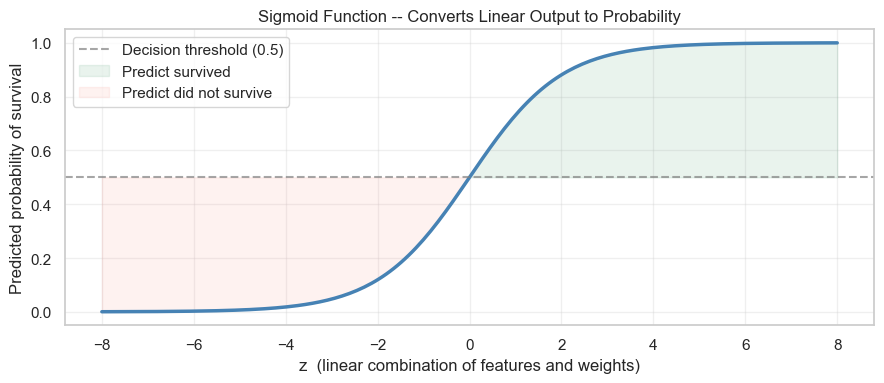

sigmoid(-8) = 0.00034  -- strongly predict negative class
sigmoid( 0) = 0.50000  -- exactly on the decision boundary
sigmoid(+8) = 0.99966  -- strongly predict positive class


In [9]:
# Visualize the sigmoid function
z_values = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z_values))

plt.figure(figsize=(9, 4))
plt.plot(z_values, sigmoid, color='steelblue', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Decision threshold (0.5)')
plt.fill_between(z_values, sigmoid, 0.5, where=(sigmoid >= 0.5),
                 alpha=0.1, color='seagreen', label='Predict survived')
plt.fill_between(z_values, sigmoid, 0.5, where=(sigmoid < 0.5),
                 alpha=0.1, color='salmon', label='Predict did not survive')
plt.xlabel('z  (linear combination of features and weights)')
plt.ylabel('Predicted probability of survival')
plt.title('Sigmoid Function -- Converts Linear Output to Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sigmoid(-8) = {1/(1+np.exp(8)):.5f}  -- strongly predict negative class")
print(f"sigmoid( 0) = {1/(1+np.exp(0)):.5f}  -- exactly on the decision boundary")
print(f"sigmoid(+8) = {1/(1+np.exp(-8)):.5f}  -- strongly predict positive class")

## 6. Train the Model

In [10]:
X = df_model[feature_cols]
y = df_model['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")
print()
print("Class distribution in train set:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("stratify=y preserves the original class ratio in both splits.")

Train: 712 rows
Test:  179 rows

Class distribution in train set:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

stratify=y preserves the original class ratio in both splits.


In [11]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("=== Test Set Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
baseline = 1 - y_test.mean()
print(f"Naive baseline (always predict majority): {baseline:.4f}")
print(f"Our improvement over baseline: +{accuracy_score(y_test, y_pred) - baseline:.4f}")

=== Test Set Results ===
Accuracy:  0.8268
Precision: 0.8276
Recall:    0.6957
F1 Score:  0.7559
ROC-AUC:   0.8589

Naive baseline (always predict majority): 0.6145
Our improvement over baseline: +0.2123


## 7. Confusion Matrix and ROC Curve

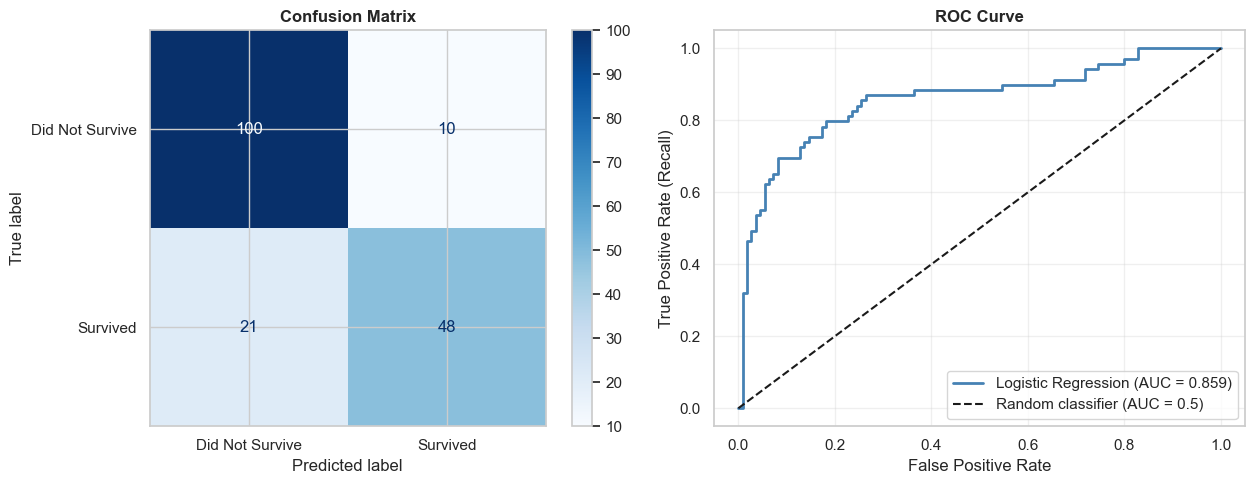

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random classifier (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.91      0.87       110
       Survived       0.83      0.70      0.76        69

       accuracy                           0.83       179
      macro avg       0.83      0.80      0.81       179
   weighted avg       0.83      0.83      0.82       179



## 8. Coefficient Interpretation

The core advantage of Logistic Regression. Every coefficient is readable and explainable.

In [14]:
coef = pipe.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': coef,
    'odds_ratio':  np.exp(coef)
}).sort_values('coefficient', ascending=False)

print(f"{'Feature':<20} {'Coefficient':>12} {'Odds Ratio':>12}  Meaning")
print("-" * 80)
for _, row in coef_df.iterrows():
    if row['odds_ratio'] > 1:
        meaning = f"each unit increase multiplies survival odds by {row['odds_ratio']:.2f}x"
    else:
        meaning = f"each unit increase multiplies survival odds by {row['odds_ratio']:.2f}x"
    print(f"{row['feature']:<20} {row['coefficient']:>12.4f} {row['odds_ratio']:>12.4f}  {meaning}")

Feature               Coefficient   Odds Ratio  Meaning
--------------------------------------------------------------------------------
sex_encoded                1.2350       3.4384  each unit increase multiplies survival odds by 3.44x
is_child                   0.3337       1.3961  each unit increase multiplies survival odds by 1.40x
embarked_Q                 0.1172       1.1243  each unit increase multiplies survival odds by 1.12x
fare_per_person            0.0708       1.0734  each unit increase multiplies survival odds by 1.07x
fare                       0.0421       1.0430  each unit increase multiplies survival odds by 1.04x
age_class                  0.0410       1.0419  each unit increase multiplies survival odds by 1.04x
parch                     -0.0768       0.9261  each unit increase multiplies survival odds by 0.93x
embarked_S                -0.1076       0.8980  each unit increase multiplies survival odds by 0.90x
family_size               -0.2807       0.7553  each un

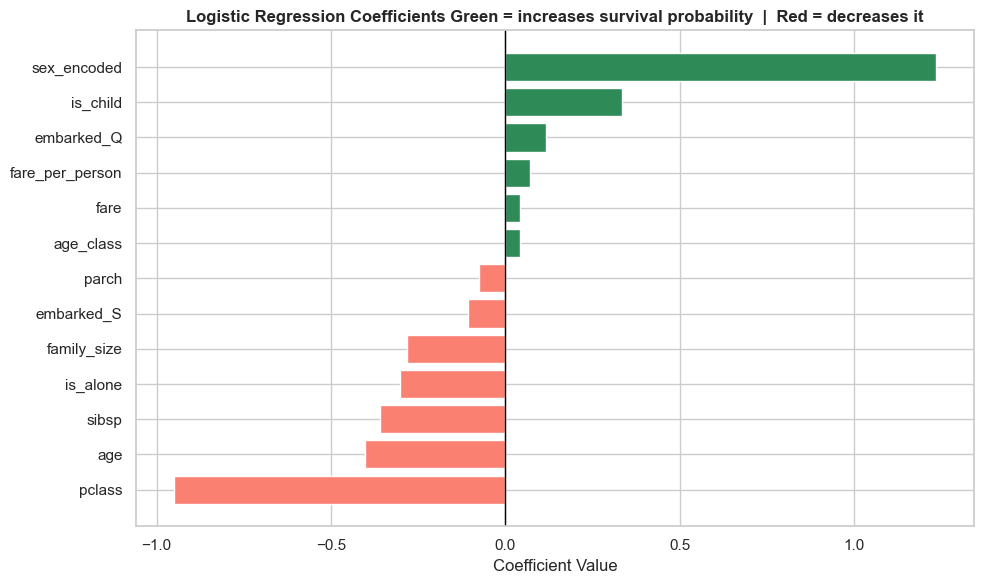

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['seagreen' if c > 0 else 'salmon' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients Green = increases survival probability  |  Red = decreases it',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Threshold Tuning

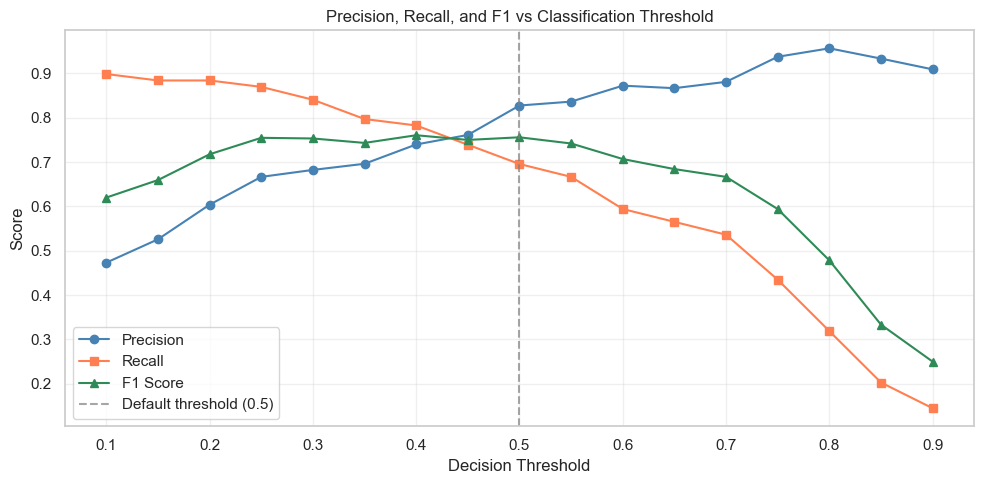

Threshold that maximizes F1: 0.40

When to adjust the threshold:
  Lower threshold -- catches more survivors (higher recall) but more false alarms (lower precision)
  Higher threshold -- fewer false alarms (higher precision) but misses more survivors (lower recall)


In [18]:
thresholds = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, 'o-', label='Precision', color='steelblue')
plt.plot(thresholds, recalls,    's-', label='Recall',    color='coral')
plt.plot(thresholds, f1s,        '^-', label='F1 Score',  color='seagreen')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_t = thresholds[np.argmax(f1s)]
print(f"Threshold that maximizes F1: {best_t:.2f}")
print()
print("When to adjust the threshold:")
print("  Lower threshold -- catches more survivors (higher recall) but more false alarms (lower precision)")
print("  Higher threshold -- fewer false alarms (higher precision) but misses more survivors (lower recall)")

## 10. Cross-Validation

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    'accuracy': cross_val_score(pipe, X, y, cv=skf, scoring='accuracy'),
    'roc_auc':  cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc'),
    'f1':       cross_val_score(pipe, X, y, cv=skf, scoring='f1'),
}

print("5-Fold Stratified Cross-Validation:")
print()
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 60)
for metric, scores in metrics.items():
    fold_str = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f}  {fold_str}")

5-Fold Stratified Cross-Validation:

Metric           Mean      Std  Fold scores
------------------------------------------------------------
accuracy       0.8081   0.0184  0.7933  0.8090  0.8034  0.7921  0.8427
roc_auc        0.8586   0.0198  0.8806  0.8631  0.8427  0.8293  0.8775
f1             0.7425   0.0258  0.7338  0.7424  0.7154  0.7299  0.7910


## 11. Effect of Regularization Parameter C

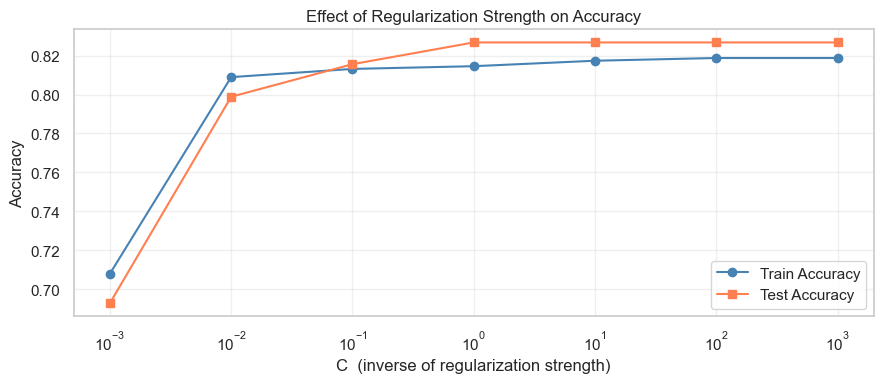

Best C: 1

Note: in Logistic Regression, C is the inverse of alpha in Ridge/Lasso.
Small C = heavy regularization = simpler model.
Large C = almost no regularization = complex model, risk of overfitting.


In [20]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores, test_scores = [], []

for C in C_values:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=C, random_state=42, max_iter=1000))
    ])
    p.fit(X_train, y_train)
    train_scores.append(p.score(X_train, y_train))
    test_scores.append(p.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.semilogx(C_values, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.semilogx(C_values, test_scores,  's-', label='Test Accuracy',  color='coral')
plt.xlabel('C  (inverse of regularization strength)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization Strength on Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C = C_values[np.argmax(test_scores)]
print(f"Best C: {best_C}")
print()
print("Note: in Logistic Regression, C is the inverse of alpha in Ridge/Lasso.")
print("Small C = heavy regularization = simpler model.")
print("Large C = almost no regularization = complex model, risk of overfitting.")

## 12. Predict on Individual Passengers

In [21]:
best_C = C_values[np.argmax(test_scores)]
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=best_C, random_state=42, max_iter=1000))
])
pipe_final.fit(X, y)

def predict_passenger(pclass, sex, age, sibsp, parch, fare, embarked):
    family_size     = sibsp + parch + 1
    is_alone        = int(family_size == 1)
    fare_per_person = fare / family_size
    is_child        = int(age < 16)
    age_class       = age * pclass
    sex_encoded     = int(sex == 'female')
    embarked_Q      = int(embarked == 'Q')
    embarked_S      = int(embarked == 'S')

    row = pd.DataFrame([[pclass, age, sibsp, parch, fare, family_size,
                          is_alone, fare_per_person, is_child, age_class,
                          sex_encoded, embarked_Q, embarked_S]],
                        columns=feature_cols)

    prob = pipe_final.predict_proba(row)[0, 1]
    label = "Survived" if prob >= 0.5 else "Did not survive"
    print(f"  Survival probability: {prob:.1%}  --  {label}")

print("First-class female, age 35, alone, fare=80, embarked at Southampton:")
predict_passenger(1, 'female', 35, 0, 0, 80, 'S')

print()
print("Third-class male, age 25, alone, fare=8, embarked at Southampton:")
predict_passenger(3, 'male', 25, 0, 0, 8, 'S')

print()
print("Second-class child, age 8, with two parents, fare=25, embarked at Cherbourg:")
predict_passenger(2, 'male', 8, 0, 2, 25, 'C')

print()
print("Third-class female, age 22, with husband, fare=14, embarked at Southampton:")
predict_passenger(3, 'female', 22, 1, 0, 14, 'S')

First-class female, age 35, alone, fare=80, embarked at Southampton:
  Survival probability: 91.7%  --  Survived

Third-class male, age 25, alone, fare=8, embarked at Southampton:
  Survival probability: 9.1%  --  Did not survive

Second-class child, age 8, with two parents, fare=25, embarked at Cherbourg:
  Survival probability: 70.8%  --  Survived

Third-class female, age 22, with husband, fare=14, embarked at Southampton:
  Survival probability: 62.6%  --  Survived


## Summary

**Strengths of Logistic Regression:**
- Highly interpretable -- coefficients and odds ratios explain every prediction
- Outputs calibrated probabilities between 0 and 1
- Fast to train, even on large datasets
- Works well when decision boundaries are approximately linear

**Weaknesses of Logistic Regression:**
- Cannot learn non-linear decision boundaries without manual feature engineering
- Assumes features contribute independently to the log-odds -- interactions must be added manually
- Performance plateau -- on complex datasets, tree-based models almost always outperform it

**Key things practiced in this notebook:**
- Binary classification with a real dataset
- Imputing missing values with group medians rather than global medians
- Feature engineering grounded in domain knowledge
- Odds ratio interpretation of coefficients
- Threshold tuning based on the precision-recall tradeoff
- Stratified cross-validation for imbalanced class problems
